## LetterBoxd Movies analysis


As we have a bigger bunch of data to process, we will prioritize efficiency at the time of processing.

For this reason, we will use Polars instead of Pandas to take advantages of their features like high processing speed and advanced filtering.

In [22]:
import polars as pl

In [2]:
df = pl.read_csv("../datasets/letterboxd_movies_dataset.csv")

In [3]:
df.head()

title,year,decade,decade_category,movie_era,age_years,age_category,runtime,runtime_category,runtime_percentile,is_feature_length,genres,primary_genre,genre_count,genre_diversity,is_single_genre,country,country_category,language,is_english,title_length,title_complexity,word_count,title_runtime_ratio,runtime_efficiency,production_scale,is_recent,is_classic
str,f64,i64,str,str,f64,str,f64,str,str,bool,str,str,f64,str,bool,str,str,str,bool,i64,str,i64,f64,str,str,bool,bool
"""Parasite""",2019.0,2010,"""2010s""","""Contemporary""",6.0,"""Recent""",133.0,"""Long""","""P90""",true,"""Thriller, Comedy""","""Thriller""",2.0,"""Dual""",false,"""South Korea""","""Asian""","""Korean""",false,8,"""Short""",1,0.06015,"""Balanced""","""Independent""",false,false
"""Barbie""",2023.0,2020,"""2020s""","""Contemporary""",2.0,"""Brand_New""",114.0,"""Standard""","""P80""",true,"""Comedy, Adventure""","""Comedy""",2.0,"""Dual""",false,"""UK""","""English_Speaking""","""English""",true,6,"""Short""",1,0.052632,"""Balanced""","""Independent""",true,false
"""Interstellar""",2014.0,2010,"""2010s""","""Contemporary""",11.0,"""Recent""",169.0,"""Long""","""P100""",true,"""Science Fiction, Adventure, Mo…","""Science Fiction""",3.0,"""Triple""",false,"""UK""","""English_Speaking""","""English""",true,12,"""Medium""",1,0.071006,"""Balanced""","""Commercial""",false,false
"""Fight Club""",1999.0,1990,"""1990s""","""Modern""",26.0,"""Modern""",139.0,"""Long""","""P100""",true,"""Thriller, Dreamlike""","""Thriller""",2.0,"""Dual""",false,"""Germany""","""European""","""English""",true,10,"""Short""",2,0.071942,"""Balanced""","""Commercial""",false,false
"""La La Land""",2016.0,2010,"""2010s""","""Contemporary""",9.0,"""Recent""",129.0,"""Long""","""P90""",true,"""Comedy, Music, Romance""","""Comedy""",3.0,"""Triple""",false,"""USA""","""English_Speaking""","""English""",true,10,"""Short""",3,0.077519,"""Balanced""","""Commercial""",false,false


In [24]:
df.columns

['title',
 'year',
 'decade',
 'decade_category',
 'movie_era',
 'age_years',
 'age_category',
 'runtime',
 'runtime_category',
 'runtime_percentile',
 'is_feature_length',
 'genres',
 'primary_genre',
 'genre_count',
 'genre_diversity',
 'is_single_genre',
 'country',
 'country_category',
 'language',
 'is_english',
 'title_length',
 'title_complexity',
 'word_count',
 'title_runtime_ratio',
 'runtime_efficiency',
 'production_scale',
 'is_recent',
 'is_classic']

In [19]:
df.drop_nans()

title,year,decade,decade_category,movie_era,age_years,age_category,runtime,runtime_category,runtime_percentile,is_feature_length,genres,primary_genre,genre_count,genre_diversity,is_single_genre,country,country_category,language,is_english,title_length,title_complexity,word_count,title_runtime_ratio,runtime_efficiency,production_scale,is_recent,is_classic
str,f64,i64,str,str,f64,str,f64,str,str,bool,str,str,f64,str,bool,str,str,str,bool,i64,str,i64,f64,str,str,bool,bool
"""Parasite""",2019.0,2010,"""2010s""","""Contemporary""",6.0,"""Recent""",133.0,"""Long""","""P90""",true,"""Thriller, Comedy""","""Thriller""",2.0,"""Dual""",false,"""South Korea""","""Asian""","""Korean""",false,8,"""Short""",1,0.06015,"""Balanced""","""Independent""",false,false
"""Barbie""",2023.0,2020,"""2020s""","""Contemporary""",2.0,"""Brand_New""",114.0,"""Standard""","""P80""",true,"""Comedy, Adventure""","""Comedy""",2.0,"""Dual""",false,"""UK""","""English_Speaking""","""English""",true,6,"""Short""",1,0.052632,"""Balanced""","""Independent""",true,false
"""Interstellar""",2014.0,2010,"""2010s""","""Contemporary""",11.0,"""Recent""",169.0,"""Long""","""P100""",true,"""Science Fiction, Adventure, Mo…","""Science Fiction""",3.0,"""Triple""",false,"""UK""","""English_Speaking""","""English""",true,12,"""Medium""",1,0.071006,"""Balanced""","""Commercial""",false,false
"""Fight Club""",1999.0,1990,"""1990s""","""Modern""",26.0,"""Modern""",139.0,"""Long""","""P100""",true,"""Thriller, Dreamlike""","""Thriller""",2.0,"""Dual""",false,"""Germany""","""European""","""English""",true,10,"""Short""",2,0.071942,"""Balanced""","""Commercial""",false,false
"""La La Land""",2016.0,2010,"""2010s""","""Contemporary""",9.0,"""Recent""",129.0,"""Long""","""P90""",true,"""Comedy, Music, Romance""","""Comedy""",3.0,"""Triple""",false,"""USA""","""English_Speaking""","""English""",true,10,"""Short""",3,0.077519,"""Balanced""","""Commercial""",false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Vendhu Thanindhathu Kaadu""",2022.0,2020,"""2020s""","""Contemporary""",3.0,"""Brand_New""",172.0,"""Long""","""P100""",true,"""Thriller, Crime""","""Thriller""",2.0,"""Dual""",false,"""India""","""Asian""","""Tamil""",false,25,"""Long""",3,0.145349,"""Verbose""","""Independent""",true,false
"""The Heart Is a Lonely Hunter""",1968.0,1960,"""1960s""","""Golden Age""",57.0,"""Classic""",123.0,"""Long""","""P90""",true,null,null,0.0,null,false,"""USA""","""English_Speaking""","""English""",true,28,"""Long""",6,0.227642,"""Very_Verbose""","""Commercial""",false,true
"""The Shipping News""",2001.0,2000,"""2000s""","""Digital""",24.0,"""Modern""",111.0,"""Standard""","""P70""",true,"""Romance""","""Romance""",1.0,"""Single""",true,"""Canada""","""Other""","""English""",true,17,"""Medium""",3,0.153153,"""Very_Verbose""","""Independent""",false,false


#### We will perform filter example for this dataset

Filter movies from the 2010s decade

In [20]:
df.filter(pl.col("decade_category") == "2010s")

title,year,decade,decade_category,movie_era,age_years,age_category,runtime,runtime_category,runtime_percentile,is_feature_length,genres,primary_genre,genre_count,genre_diversity,is_single_genre,country,country_category,language,is_english,title_length,title_complexity,word_count,title_runtime_ratio,runtime_efficiency,production_scale,is_recent,is_classic
str,f64,i64,str,str,f64,str,f64,str,str,bool,str,str,f64,str,bool,str,str,str,bool,i64,str,i64,f64,str,str,bool,bool
"""Parasite""",2019.0,2010,"""2010s""","""Contemporary""",6.0,"""Recent""",133.0,"""Long""","""P90""",true,"""Thriller, Comedy""","""Thriller""",2.0,"""Dual""",false,"""South Korea""","""Asian""","""Korean""",false,8,"""Short""",1,0.06015,"""Balanced""","""Independent""",false,false
"""Interstellar""",2014.0,2010,"""2010s""","""Contemporary""",11.0,"""Recent""",169.0,"""Long""","""P100""",true,"""Science Fiction, Adventure, Mo…","""Science Fiction""",3.0,"""Triple""",false,"""UK""","""English_Speaking""","""English""",true,12,"""Medium""",1,0.071006,"""Balanced""","""Commercial""",false,false
"""La La Land""",2016.0,2010,"""2010s""","""Contemporary""",9.0,"""Recent""",129.0,"""Long""","""P90""",true,"""Comedy, Music, Romance""","""Comedy""",3.0,"""Triple""",false,"""USA""","""English_Speaking""","""English""",true,10,"""Short""",3,0.077519,"""Balanced""","""Commercial""",false,false
"""Whiplash""",2014.0,2010,"""2010s""","""Contemporary""",11.0,"""Recent""",107.0,"""Standard""","""P60""",true,"""Music""","""Music""",1.0,"""Single""",true,"""USA""","""English_Speaking""","""English""",true,8,"""Short""",1,0.074766,"""Balanced""","""Independent""",false,false
"""Joker""",2019.0,2010,"""2010s""","""Contemporary""",6.0,"""Recent""",122.0,"""Long""","""P90""",true,"""Thriller, Crime""","""Thriller""",2.0,"""Dual""",false,"""Canada""","""Other""","""English""",true,5,"""Short""",1,0.040984,"""Efficient""","""Commercial""",false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Crystal Swan""",2018.0,2010,"""2010s""","""Contemporary""",7.0,"""Recent""",94.0,"""Standard""","""P40""",true,null,null,0.0,null,false,"""Germany""","""European""","""Russian""",false,12,"""Medium""",2,0.12766,"""Verbose""","""Independent""",false,false
"""Girls with Balls""",2018.0,2010,"""2010s""","""Contemporary""",7.0,"""Recent""",77.0,"""Short""","""P10""",false,"""Horror, Comedy""","""Horror""",2.0,"""Dual""",false,"""Belgium""","""Other""","""French""",false,16,"""Medium""",3,0.207792,"""Very_Verbose""","""Independent""",false,false
"""Kids on the Slope""",2012.0,2010,"""2010s""","""Contemporary""",13.0,"""Recent""",288.0,"""Epic""","""P100""",true,"""Animation""","""Animation""",1.0,"""Single""",true,"""Japan""","""Asian""","""Japanese""",false,17,"""Medium""",4,0.059028,"""Balanced""","""Epic""",false,false


#### Selecting all the animation movies

In [21]:
animation_movies = df.filter(pl.col("genres") == "Animation")
animation_movies["title"]

title
str
"""Look Back"""
"""Persepolis"""
"""From Up on Poppy Hill"""
"""If Anything Happens I Love You"""
"""Save Ralph"""
…
"""Eye Myth"""
"""The Dream of a Ridiculous Man"""
"""Dead End."""


### s

In [25]:
import seaborn as sb

Suppose you want to make a comparison of movies for each era.

We want to enumerate these eras

In [31]:
df.select(["movie_era"]).unique

<bound method DataFrame.unique of shape: (16_246, 1)
┌──────────────┐
│ movie_era    │
│ ---          │
│ str          │
╞══════════════╡
│ Contemporary │
│ Contemporary │
│ Contemporary │
│ Modern       │
│ Contemporary │
│ …            │
│ Contemporary │
│ Golden Age   │
│ Digital      │
│ Digital      │
│ Classic      │
└──────────────┘>

There was a total of 4 movie eras

Text(0, 0.5, 'Total')

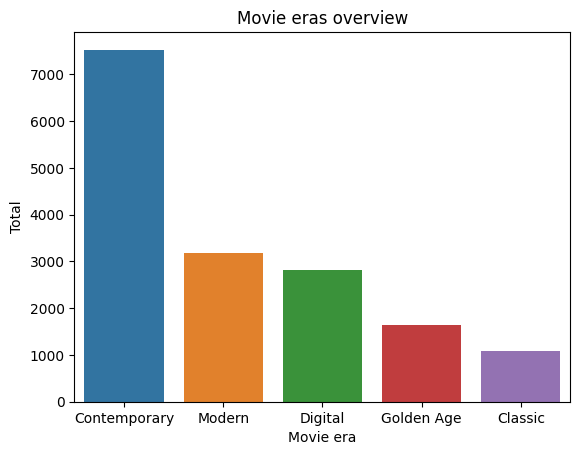

In [57]:
movie_plot = sb.countplot(data=df,x="movie_era",hue="movie_era")
movie_plot.set_title("Movie eras overview")
movie_plot.set_xlabel("Movie era")
movie_plot.set_ylabel("Total")

In [83]:
efficient_runtime = df.filter(pl.col("runtime_efficiency") == "Efficient")
efficient_runtime.count()

title,year,decade,decade_category,movie_era,age_years,age_category,runtime,runtime_category,runtime_percentile,is_feature_length,genres,primary_genre,genre_count,genre_diversity,is_single_genre,country,country_category,language,is_english,title_length,title_complexity,word_count,title_runtime_ratio,runtime_efficiency,production_scale,is_recent,is_classic
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1186,1186,1186,1186,1186,1186,1145,1183,1183,1186,1186,1055,1055,1186,1055,1186,1186,1186,1186,1186,1186,1186,1186,1186,1186,1186,1186,1186


Now we know there was a total of 1186 which had an efficient runtime performance

Now let's group the total number of movies with this condition for each movie era

In [109]:
efficient_runtime.group_by("movie_era").agg(pl.len().alias("Total"))

movie_era,Total
str,u32
"""Classic""",32
"""Modern""",166
"""Digital""",181
"""Contemporary""",717
"""Golden Age""",90
